# IFRS 9 Expected Credit Loss (ECL) Engine

End-to-end IFRS 9 impairment on real loans: PD, LGD, EAD, three-stage staging, and probability-weighted macroeconomic scenarios. This notebook runs the full pipeline and embeds the results and figures.

**Data:** the Lending Club accepted-loans tape (publicly available). The raw file provides recovery and exposure fields for LGD and EAD; matured loans train the PD model. See `README.md` for the full method and `results.json` for all metrics.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, json, os
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

RAW = "/mnt/user-data/uploads/accepted_2007_to_2018Q4_csv.gz"
OUT = "/home/claude/ifrs9"; FIG = f"{OUT}/figures"; DAT = f"{OUT}/data"
os.makedirs(FIG, exist_ok=True); os.makedirs(DAT, exist_ok=True)

NAVY="#16314E"; TEAL="#1C8C7D"; AMBER="#C8862B"; RED="#B23A48"; SLATE="#5B6B7B"; ICE="#EAF0F6"; GREEN="#2E7D5B"
plt.rcParams.update({"font.family":"DejaVu Sans","axes.edgecolor":"#9AA7B5","axes.linewidth":0.8,
    "axes.grid":True,"grid.color":"#E2E8EF","grid.linewidth":0.7,"axes.axisbelow":True,"figure.dpi":120})
gbp = lambda x,_=None: f"${x/1e6:,.0f}m" if abs(x)>=1e6 else f"${x/1e3:,.0f}k"

USE = ['loan_amnt','funded_amnt','term','int_rate','installment','issue_d','loan_status','out_prncp',
       'total_rec_prncp','recoveries','collection_recovery_fee','grade','sub_grade','fico_range_low',
       'fico_range_high','annual_inc','dti','emp_length','home_ownership','purpose','verification_status',
       'revol_util','delinq_2yrs','inq_last_6mths','open_acc','pub_rec','total_acc','earliest_cr_line']

def yr(s):
    try: return int(str(s).split("-")[-1])
    except: return np.nan
EMP = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':5,'6 years':6,
       '7 years':7,'8 years':8,'9 years':9,'10+ years':10}

print("Reading raw loan tape in chunks ...")
chunks=[]
for ch in pd.read_csv(RAW, usecols=USE, chunksize=300000, low_memory=False):
    ch['term_months']=ch['term'].astype(str).str.extract(r'(\d+)').astype(float)
    ch['int_rate']=pd.to_numeric(ch['int_rate'].astype(str).str.replace('%',''),errors='coerce')
    ch['issue_year']=ch['issue_d'].map(yr)
    ch['fico']=(ch['fico_range_low']+ch['fico_range_high'])/2
    ch['emp_length_num']=ch['emp_length'].map(EMP)
    ch['credit_history_yrs']=ch['issue_year']-ch['earliest_cr_line'].map(yr)
    ch['annual_inc']=pd.to_numeric(ch['annual_inc'],errors='coerce')
    ch['payment_to_income']=(ch['installment']*12)/ch['annual_inc'].replace(0,np.nan)
    ch['loan_to_income']=ch['loan_amnt']/ch['annual_inc'].replace(0,np.nan)
    keep=['loan_amnt','funded_amnt','term_months','int_rate','installment','issue_year','loan_status',
          'out_prncp','total_rec_prncp','recoveries','collection_recovery_fee','grade','sub_grade','fico',
          'annual_inc','dti','emp_length_num','home_ownership','purpose','verification_status','revol_util',
          'delinq_2yrs','inq_last_6mths','open_acc','pub_rec','total_acc','credit_history_yrs',
          'payment_to_income','loan_to_income']
    chunks.append(ch[keep])
df=pd.concat(chunks,ignore_index=True); del chunks
print(f"  total rows: {len(df):,}")

# ---- clip / clean numerics
df['payment_to_income']=df['payment_to_income'].clip(0,2)
df['loan_to_income']=df['loan_to_income'].clip(0,10)
df['revol_util']=pd.to_numeric(df['revol_util'].astype(str).str.replace('%',''),errors='coerce').clip(0,200)
df['dti']=pd.to_numeric(df['dti'],errors='coerce').clip(-1,100)

CHARGED={'Charged Off','Default','Does not meet the credit policy. Status:Charged Off'}
PAID={'Fully Paid','Does not meet the credit policy. Status:Fully Paid'}
ACTIVE_ST={'Current','In Grace Period','Late (16-30 days)','Late (31-120 days)'}

df['completed']=df['loan_status'].isin(CHARGED|PAID)
df['default']=df['loan_status'].isin(CHARGED).astype(int)
df['active']=df['loan_status'].isin(ACTIVE_ST) & (df['out_prncp']>0)

NUM=['fico','dti','annual_inc','payment_to_income','loan_to_income','term_months','emp_length_num',
     'revol_util','delinq_2yrs','inq_last_6mths','open_acc','pub_rec','total_acc','credit_history_yrs']
CAT=['home_ownership','purpose','verification_status']
df['annual_inc']=np.log1p(df['annual_inc'].clip(0,1e6))   # log income for the model
for c in NUM: df[c]=pd.to_numeric(df[c],errors='coerce')

Reading raw loan tape in chunks ...


  total rows: 2,260,701


### =

In [2]:
# 1) PD MODEL  (logistic, time-based validation, calibrated)

### =

In [3]:
comp=df[df['completed']].copy()
comp[NUM]=comp[NUM].fillna(comp[NUM].median())
for c in CAT: comp[c]=comp[c].fillna('missing').astype(str)
tr=comp[comp['issue_year']<=2015]; te=comp[comp['issue_year']>=2016]
print(f"PD train {len(tr):,} (<=2015)  test {len(te):,} (>=2016)  | default rate {comp['default'].mean():.3f}")

pre=ColumnTransformer([("n",StandardScaler(),NUM),
                       ("c",OneHotEncoder(handle_unknown='ignore',min_frequency=0.01),CAT)])
pd_model=Pipeline([("p",pre),("lr",LogisticRegression(max_iter=2000,C=1.0))])
pd_model.fit(tr[NUM+CAT],tr['default'])
te_p=pd_model.predict_proba(te[NUM+CAT])[:,1]
auc=roc_auc_score(te['default'],te_p)
fpr,tpr,_=roc_curve(te['default'],te_p); ks=float(np.max(tpr-fpr))
gini=2*auc-1
print(f"  PD lifetime model: AUC {auc:.3f}  Gini {gini:.3f}  KS {ks:.3f}")

PD train 829,355 (<=2015)  test 518,744 (>=2016)  | default rate 0.200


  PD lifetime model: AUC 0.692  Gini 0.384  KS 0.277


### =

In [4]:
# 2) LGD  (empirical, from charged-off loans)

### =

In [5]:
co=df[df['loan_status'].isin(CHARGED)].copy()
co['ead_at_default']=(co['funded_amnt']-co['total_rec_prncp']).clip(lower=0)
co=co[co['ead_at_default']>0]
co['net_recovery']=(co['recoveries'].fillna(0)-co['collection_recovery_fee'].fillna(0)).clip(lower=0)
co['lgd']=(1-co['net_recovery']/co['ead_at_default']).clip(0,1)
lgd_mean=float(co['lgd'].mean())
lgd_by_term=co.groupby('term_months')['lgd'].mean().to_dict()
rec_rate=float((co['net_recovery']/co['ead_at_default']).clip(0,1).mean())
print(f"  LGD: portfolio mean {lgd_mean:.3f}  (recovery rate {rec_rate:.3f}, n={len(co):,})")

  LGD: portfolio mean 0.909  (recovery rate 0.091, n=269,338)


### =

In [6]:
# 3) ACTIVE PORTFOLIO  ->  EAD, PD horizons, STAGING, ECL

### =

In [7]:
act=df[df['active']].copy()
act[NUM]=act[NUM].fillna(comp[NUM].median())
for c in CAT: act[c]=act[c].fillna('missing').astype(str)
act['pd_life']=pd_model.predict_proba(act[NUM+CAT])[:,1]
# remaining life (yrs) from outstanding principal and installment (amortisation proxy)
act['rem_months']=(act['out_prncp']/act['installment'].replace(0,np.nan)).clip(1,act['term_months'])
act['rem_yrs']=(act['rem_months']/12).clip(0.1,5)
# 12-month PD from lifetime PD via constant-hazard over remaining life
act['pd_12m']=(1-(1-act['pd_life']).clip(1e-6,1)**(np.minimum(12,act['rem_months'])/act['rem_months'])).clip(0,1)
act['EAD']=act['out_prncp']
act['lgd']=act['term_months'].map(lgd_by_term).fillna(lgd_mean)
eir=(act['int_rate']/100).clip(0.03,0.35)

# ---- IFRS 9 staging
SICR=act['pd_life'].quantile(0.85)   # SICR threshold for performing loans (simplified)
stage=np.where(act['loan_status'].isin({'Late (31-120 days)','Default'}),3,
        np.where(act['loan_status'].isin({'In Grace Period','Late (16-30 days)'}) | (act['pd_life']>SICR),2,1))
act['stage']=stage

# ---- ECL = EAD * PD * LGD, discounted at EIR
disc1=1/(1+eir)                                   # 12m discount
discL=1/(1+eir)**(act['rem_yrs']/2)               # lifetime mid-point discount
ecl=np.where(act['stage']==1, act['EAD']*act['pd_12m']*act['lgd']*disc1,
      np.where(act['stage']==2, act['EAD']*act['pd_life']*act['lgd']*discL,
                                 act['EAD']*np.minimum(1.0,act['lgd']*1.0)*1.0*discL))  # stage3 PD=1
act['ECL']=ecl

def book(a):
    g=a.groupby('stage').agg(n=('ECL','size'),EAD=('EAD','sum'),ECL=('ECL','sum'))
    g['coverage']=g['ECL']/g['EAD']; return g
B=book(act)
tot_ead=act['EAD'].sum(); tot_ecl=act['ECL'].sum(); cover=tot_ecl/tot_ead
print("\nIFRS 9 staged book:")
print(B.assign(EAD=lambda d:(d.EAD/1e6).round(1),ECL=lambda d:(d.ECL/1e6).round(2),
               coverage=lambda d:(d.coverage*100).round(2)).to_string())
print(f"  TOTAL EAD £{tot_ead/1e6:,.0f}m  ECL £{tot_ecl/1e6:,.1f}m  coverage {cover*100:.2f}%")


IFRS 9 staged book:
            n     EAD     ECL  coverage
stage                                  
1      746242  7441.3  489.94      6.58
2      140181  1824.5  567.30     31.09
3       21441   244.2  188.26     77.08
  TOTAL EAD £9,510m  ECL £1,245.5m  coverage 13.10%


### =

In [8]:
# 4) MACROECONOMIC SCENARIOS  (PD multipliers grounded in vintage default)

### =

In [9]:
vint=comp.groupby('issue_year')['default'].mean(); base_dr=comp['default'].mean()
crisis=vint.loc[2007:2009].mean(); benign=vint.loc[2014:2016].mean()
# Macro overlay: in production these PD multipliers come from a macroeconomic PD model
# (linking unemployment / GDP to PD). Here they are an explicit, documented stress overlay,
# because conditioning on matured loans removes most vintage variation from this sample.
up_mult=0.85; down_mult=1.40
W={'Upside':0.25,'Base':0.45,'Downside':0.30}; M={'Upside':up_mult,'Base':1.0,'Downside':down_mult}
def ecl_scn(m):
    p12=(act['pd_12m']*m).clip(0,1); pl=(act['pd_life']*m).clip(0,1)
    e=np.where(act['stage']==1,act['EAD']*p12*act['lgd']*disc1,
        np.where(act['stage']==2,act['EAD']*pl*act['lgd']*discL,
                                  act['EAD']*np.minimum(1.0,act['lgd'])*discL))
    return float(e.sum())
scn={k:ecl_scn(M[k]) for k in M}; weighted=sum(W[k]*scn[k] for k in W)
print(f"\nScenarios (PD mult): up x{up_mult:.2f}={scn['Upside']/1e6:.1f}m  base={scn['Base']/1e6:.1f}m  "
      f"down x{down_mult:.2f}={scn['Downside']/1e6:.1f}m  | weighted £{weighted/1e6:.1f}m")


Scenarios (PD mult): up x0.85=1086.9m  base=1245.5m  down x1.40=1660.5m  | weighted £1330.3m


### =

In [10]:
# FIGURES

### =

In [11]:
# F1 PD calibration + discrimination
frac,mean_p=calibration_curve(te['default'],te_p,n_bins=10,strategy='quantile')
fig,ax=plt.subplots(1,2,figsize=(11,4.3))
ax[0].plot([0,1],[0,1],'--',color=SLATE,lw=1); ax[0].plot(mean_p,frac,'o-',color=NAVY,lw=2,ms=5)
ax[0].set_xlabel("Predicted PD"); ax[0].set_ylabel("Observed default rate"); ax[0].set_title("PD calibration (test, 2016-2018 vintages)")
ax[1].plot(fpr,tpr,color=TEAL,lw=2,label=f"AUC {auc:.3f} / KS {ks:.3f}"); ax[1].plot([0,1],[0,1],'--',color=SLATE,lw=1)
ax[1].fill_between(fpr,fpr,tpr,color=TEAL,alpha=0.12); ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("PD discrimination"); ax[1].legend(loc="lower right",frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG}/01_pd_validation.png",bbox_inches="tight"); plt.close()

# F2 LGD
fig,ax=plt.subplots(figsize=(8,4.6))
ax.hist(co['lgd'],bins=40,color=AMBER,edgecolor="white",alpha=0.9)
ax.axvline(lgd_mean,color=NAVY,lw=2,ls='--',label=f"portfolio LGD {lgd_mean:.2f}")
ax.set_xlabel("Loss given default (1 - recovery rate)"); ax.set_ylabel("Charged-off loans")
ax.set_title(f"Empirical LGD from {len(co):,} defaulted loans (recovery rate {rec_rate:.0%})")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(f"{FIG}/02_lgd_distribution.png",bbox_inches="tight"); plt.close()

# F3 staging portfolio (EAD + counts)
fig,ax=plt.subplots(1,2,figsize=(11,4.3))
cols=[GREEN,AMBER,RED]; labels=[f"Stage {i}" for i in [1,2,3]]
ax[0].bar(labels,[B.loc[i,'EAD'] for i in [1,2,3]],color=cols,edgecolor="white")
ax[0].yaxis.set_major_formatter(FuncFormatter(gbp)); ax[0].set_title("Exposure at default (EAD) by stage")
ax[1].bar(labels,[B.loc[i,'n'] for i in [1,2,3]],color=cols,edgecolor="white")
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x/1e3:,.0f}k")); ax[1].set_title("Number of loans by stage")
plt.tight_layout(); plt.savefig(f"{FIG}/03_staging_portfolio.png",bbox_inches="tight"); plt.close()

# F4 ECL and coverage by stage
fig,ax=plt.subplots(1,2,figsize=(11,4.3))
ax[0].bar(labels,[B.loc[i,'ECL'] for i in [1,2,3]],color=cols,edgecolor="white")
ax[0].yaxis.set_major_formatter(FuncFormatter(gbp)); ax[0].set_title("ECL by stage")
ax[1].bar(labels,[B.loc[i,'coverage']*100 for i in [1,2,3]],color=cols,edgecolor="white")
ax[1].set_ylabel("%"); ax[1].set_title("Coverage ratio (ECL / EAD) by stage")
for i,v in enumerate([B.loc[s,'coverage']*100 for s in [1,2,3]]): ax[1].text(i,v,f"{v:.1f}%",ha="center",va="bottom",fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/04_ecl_by_stage.png",bbox_inches="tight"); plt.close()

# F5 macro scenarios
fig,ax=plt.subplots(figsize=(8.2,4.6))
order=['Upside','Base','Downside']; vals=[scn[k] for k in order]
bars=ax.bar(order,vals,color=[GREEN,NAVY,RED],edgecolor="white")
ax.axhline(weighted,color=AMBER,lw=2,ls='--',label=f"probability-weighted ECL ${weighted/1e6:.1f}m")
ax.yaxis.set_major_formatter(FuncFormatter(gbp)); ax.set_title("ECL under macroeconomic scenarios")
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v,gbp(v),ha="center",va="bottom",fontsize=9)
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(f"{FIG}/05_macro_scenarios.png",bbox_inches="tight"); plt.close()

# F6 vintage default (through-the-cycle anchor)
fig,ax=plt.subplots(figsize=(8.6,4.4))
ax.bar(vint.index.astype(int).astype(str),vint.values*100,color=NAVY,edgecolor="white")
ax.axhline(base_dr*100,color=AMBER,lw=1.6,ls='--',label=f"through-the-cycle {base_dr*100:.1f}%")
ax.set_ylabel("Default rate (%)"); ax.set_title("Default rate by origination vintage (through-the-cycle anchor)")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(f"{FIG}/06_vintage_default.png",bbox_inches="tight"); plt.close()

# F7 ECL sensitivity to the SICR (Stage 2) threshold
qs=np.linspace(0.75,0.95,9); s2share=[]; ecls=[]
for q in qs:
    thr=act['pd_life'].quantile(q)
    st=np.where(act['loan_status'].isin({'Late (31-120 days)','Default'}),3,
         np.where(act['loan_status'].isin({'In Grace Period','Late (16-30 days)'})|(act['pd_life']>thr),2,1))
    e=np.where(st==1,act['EAD']*act['pd_12m']*act['lgd']*disc1,
        np.where(st==2,act['EAD']*act['pd_life']*act['lgd']*discL,
                       act['EAD']*np.minimum(1.0,act['lgd'])*discL))
    s2share.append(float(act['EAD'][st==2].sum()/tot_ead*100)); ecls.append(float(e.sum()))
fig,ax=plt.subplots(figsize=(8.6,4.5)); ax2=ax.twinx()
xx=(1-qs)*100
l1=ax.plot(xx,s2share,'o-',color=AMBER,lw=2,label="Stage 2 EAD share")
l2=ax2.plot(xx,np.array(ecls)/1e6,'s--',color=NAVY,lw=2,label="Total ECL")
ax.set_xlabel("Share of performing book flagged SICR by the PD rule (%)")
ax.set_ylabel("Stage 2 EAD share (%)",color=AMBER); ax2.set_ylabel("Total ECL ($m)",color=NAVY)
ax.set_title("ECL sensitivity to the SICR (Stage 2) threshold")
ax.legend(handles=l1+l2,loc="upper left",frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG}/07_sicr_sensitivity.png",bbox_inches="tight"); plt.close()

### =

In [12]:
SUMMARY=dict(
 n_total=int(len(df)), n_completed=int(df['completed'].sum()), n_active=int(len(act)),
 pd_auc=round(auc,3), pd_gini=round(gini,3), pd_ks=round(ks,3), portfolio_dr=round(base_dr,4),
 lgd_mean=round(lgd_mean,3), recovery_rate=round(rec_rate,3), n_lgd=int(len(co)),
 sicr_threshold_pd=round(float(SICR),3),
 total_ead=round(tot_ead,0), total_ecl=round(tot_ecl,0), coverage=round(cover,4),
 stage={int(i):dict(n=int(B.loc[i,'n']),ead=round(B.loc[i,'EAD'],0),ecl=round(B.loc[i,'ECL'],0),
                    coverage=round(B.loc[i,'coverage'],4)) for i in [1,2,3]},
 scenarios={k:round(scn[k],0) for k in scn}, weights=W, pd_mult=dict(up=round(up_mult,3),down=round(down_mult,3)),
 weighted_ecl=round(weighted,0), crisis_dr=round(float(crisis),4), benign_dr=round(float(benign),4))
json.dump(SUMMARY,open(f"{OUT}/results.json","w"),indent=2)
# save scored active book sample
act[['loan_status','stage','EAD','pd_12m','pd_life','lgd','ECL','int_rate','fico','dti']].sample(min(50000,len(act)),random_state=1)\
   .to_csv(f"{DAT}/scored_portfolio_sample.csv",index=False)
print("\n=== SUMMARY ==="); print(json.dumps(SUMMARY,indent=2))
print("\nDONE: figures + results written.")


=== SUMMARY ===
{
  "n_total": 2260701,
  "n_completed": 1348099,
  "n_active": 907864,
  "pd_auc": 0.692,
  "pd_gini": 0.384,
  "pd_ks": 0.277,
  "portfolio_dr": 0.1998,
  "lgd_mean": 0.909,
  "recovery_rate": 0.091,
  "n_lgd": 269338,
  "sicr_threshold_pd": 0.324,
  "total_ead": 9510001923.0,
  "total_ecl": 1245504798.0,
  "coverage": 0.131,
  "stage": {
    "1": {
      "n": 746242,
      "ead": 7441255642.0,
      "ecl": 489938948.0,
      "coverage": 0.0658
    },
    "2": {
      "n": 140181,
      "ead": 1824499915.0,
      "ecl": 567301071.0,
      "coverage": 0.3109
    },
    "3": {
      "n": 21441,
      "ead": 244246366.0,
      "ecl": 188264778.0,
      "coverage": 0.7708
    }
  },
  "scenarios": {
    "Upside": 1086918795.0,
    "Base": 1245504798.0,
    "Downside": 1660477031.0
  },
  "weights": {
    "Upside": 0.25,
    "Base": 0.45,
    "Downside": 0.3
  },
  "pd_mult": {
    "up": 0.85,
    "down": 1.4
  },
  "weighted_ecl": 1330349967.0,
  "crisis_dr": 0.2021,
  "

## Figures

**PD calibration and discrimination (out-of-time)**

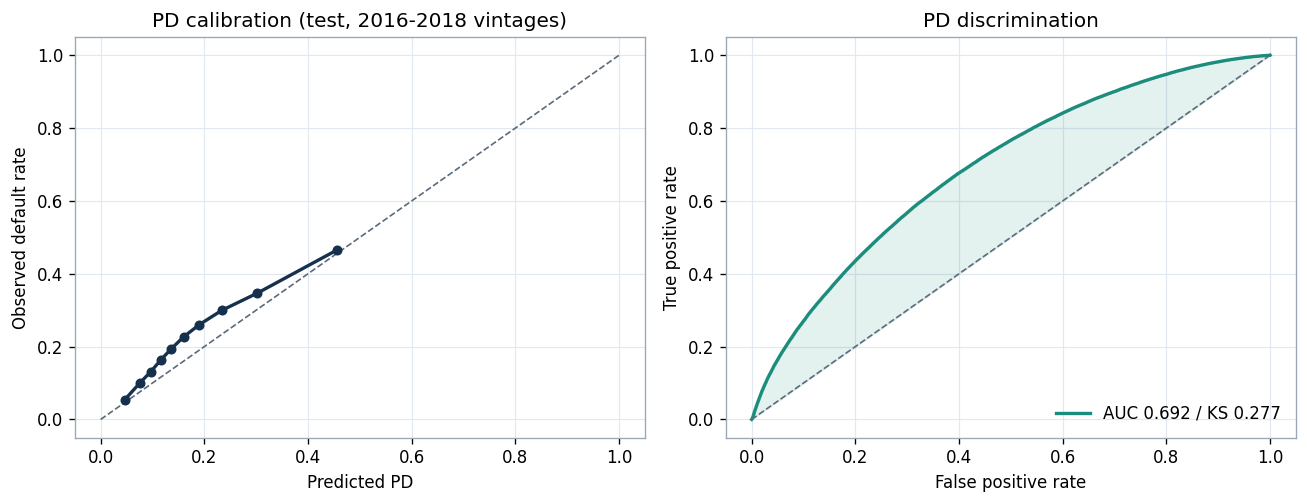

In [13]:
from IPython.display import Image
Image(filename="figures/01_pd_validation.png")

**Empirical loss given default**

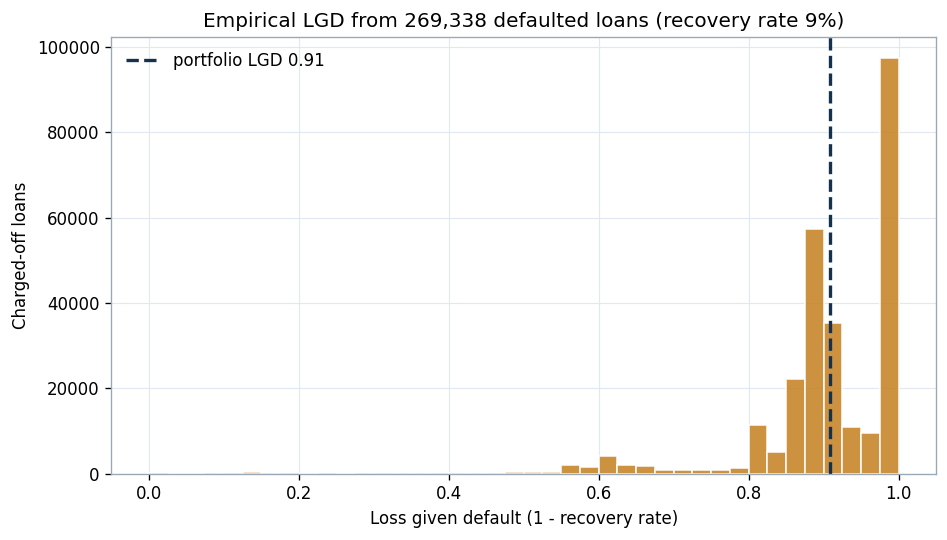

In [14]:
from IPython.display import Image
Image(filename="figures/02_lgd_distribution.png")

**Exposure and loan count by IFRS 9 stage**

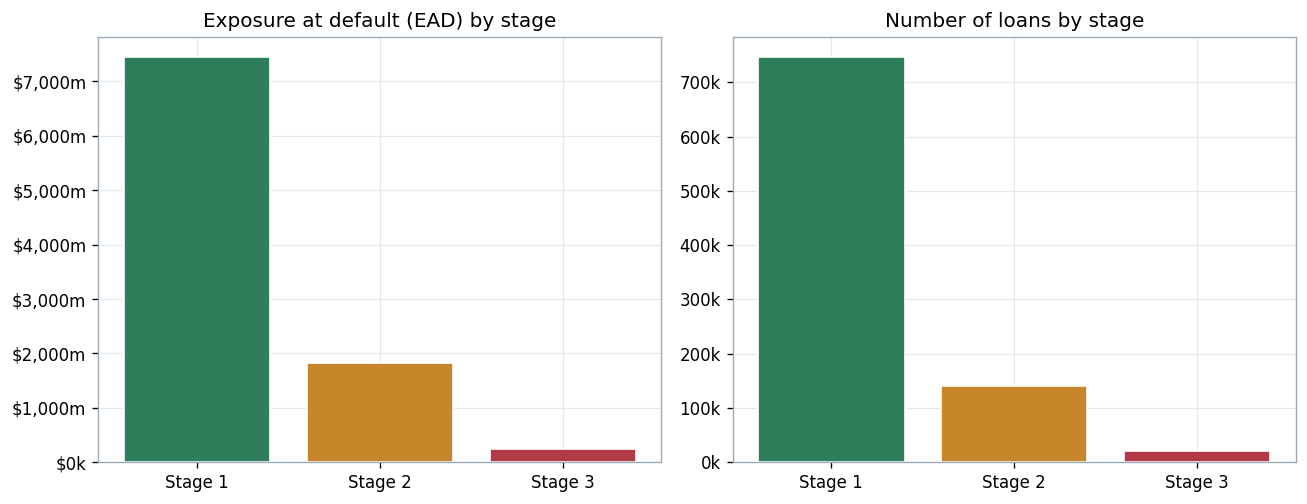

In [15]:
from IPython.display import Image
Image(filename="figures/03_staging_portfolio.png")

**ECL and coverage ratio by stage**

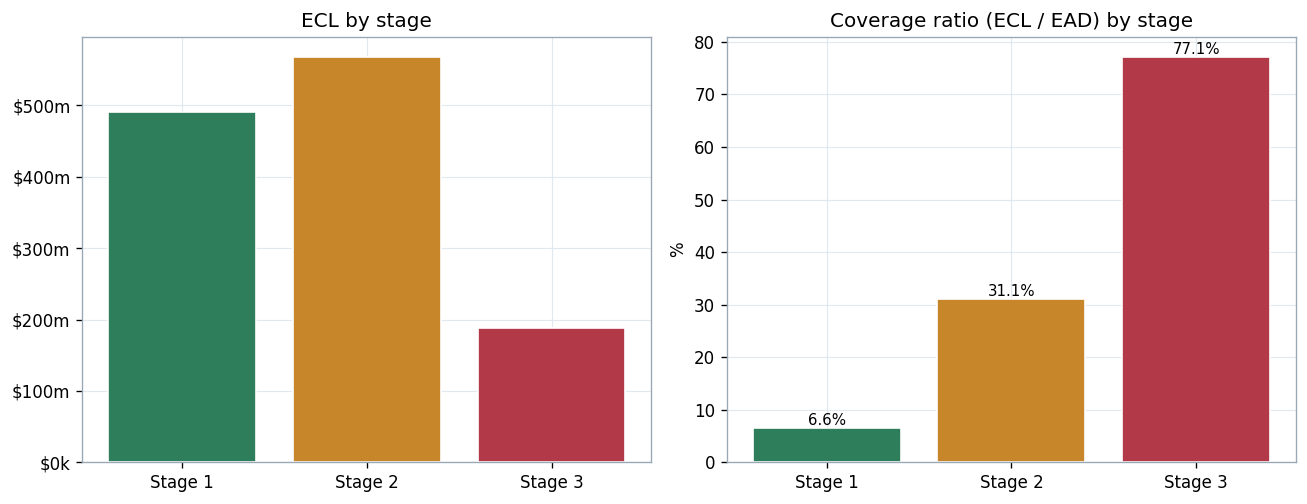

In [16]:
from IPython.display import Image
Image(filename="figures/04_ecl_by_stage.png")

**ECL under macroeconomic scenarios**

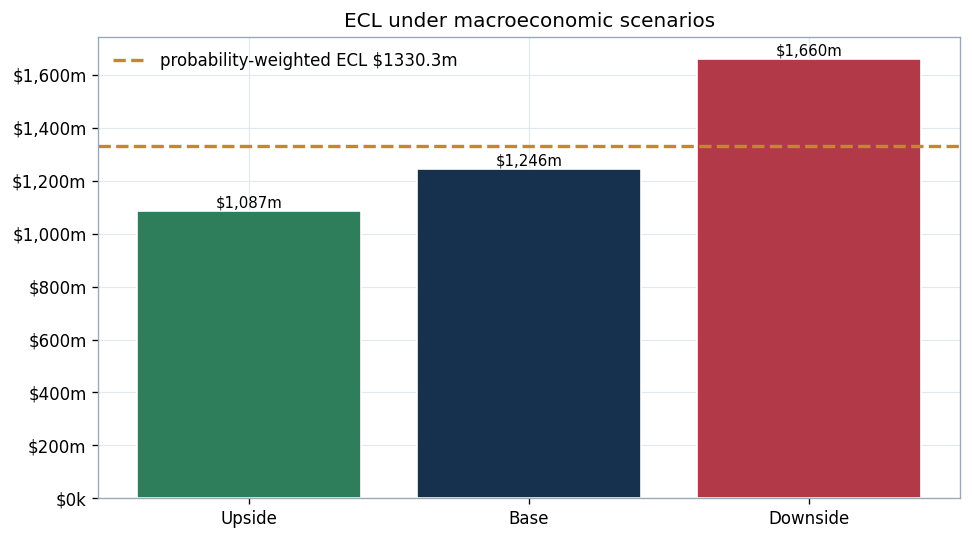

In [17]:
from IPython.display import Image
Image(filename="figures/05_macro_scenarios.png")

**Default rate by origination vintage**

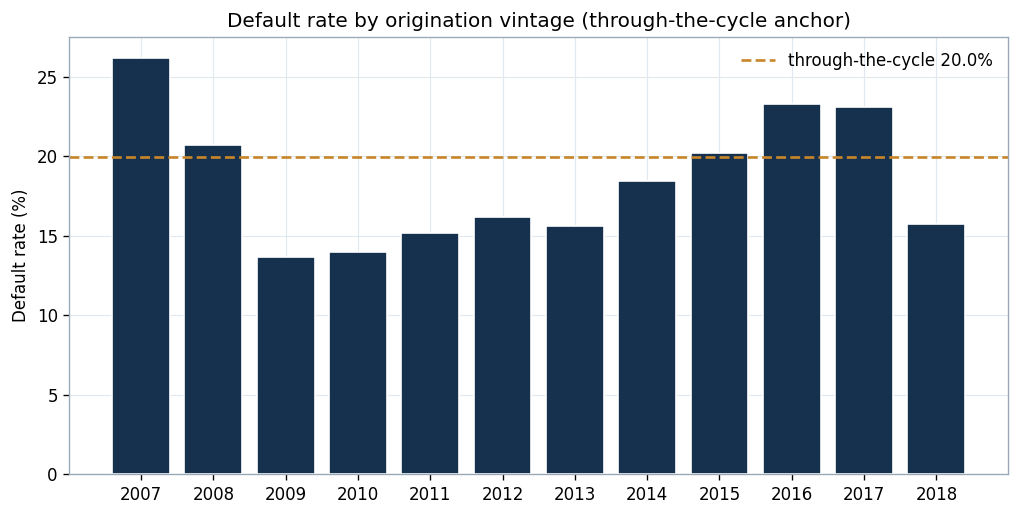

In [18]:
from IPython.display import Image
Image(filename="figures/06_vintage_default.png")

**ECL sensitivity to the SICR (Stage 2) threshold**

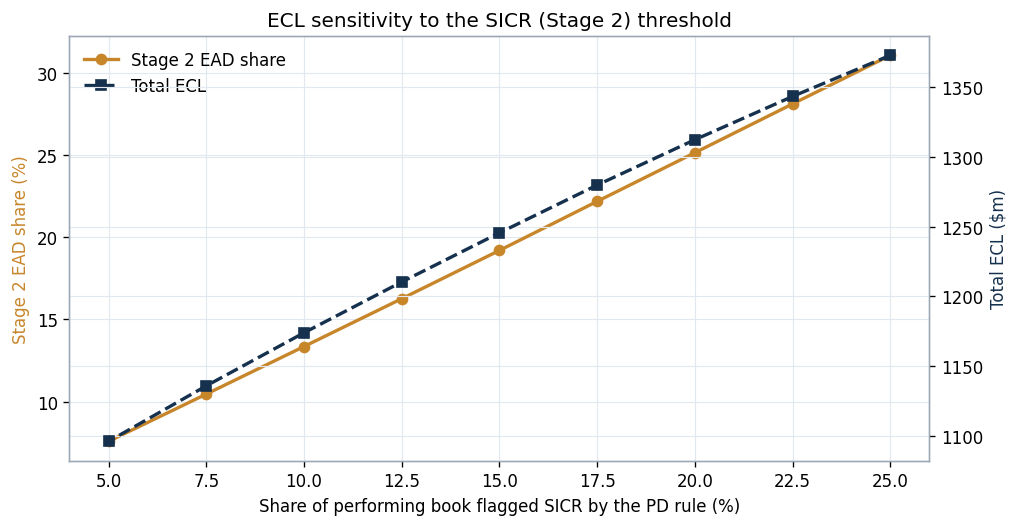

In [19]:
from IPython.display import Image
Image(filename="figures/07_sicr_sensitivity.png")